# Hessian Spectral Analysis

The stability and generalization properties of the SDE are determined by the geometry of the loss landscape $L(\theta)$. We analyze this geometry through the **Hessian Matrix** $H(\theta) = \nabla^2 L(\theta)$, which identifies the local curvature of the parameter space.

### 1. Curvature and Eigenvalues
The eigenvalues $\{\lambda_1, \lambda_2, \dots, \lambda_n\}$ of the Hessian represent the curvature along the principal axes. 

* **Sharp Minima ($\lambda_{max}$ is large):** Small perturbations in $\theta$ lead to a massive increase in loss. These regions are often associated with poor generalization.
* **Flat Minima ($\lambda_{max}$ is small):** The loss surface is broad and forgiving. Noise-induced drift in our SDE helps the model "bounce" out of sharp wells to find these stable, flat regions.



---

### 2. Spectral Gap and Relaxation Time
The **Spectral Gap**—the distance between the lowest and highest eigenvalues—dictates the convergence rate of the Langevin dynamics. In the localized approximation of our SDE:
$$d\theta_t = -H(\theta_t - \theta^*) dt + \sqrt{2\gamma} dW_t$$

The time required for the distribution to reach a steady state is inversely proportional to the spectral gap. A narrow gap implies "slow mixing," where the model takes longer to explore the parameters.

---

### 3. Stability Bounds for Euler-Maruyama
For our numerical simulation to remain stable (i.e., not diverge to infinity), the discrete time step $\Delta t$ (the learning rate) must satisfy the following condition relative to the maximum curvature:
$$\Delta t < \frac{2}{\lambda_{max}}$$

If the curvature becomes too sharp and $\Delta t$ is not decreased, the "stochastic kick" from the diffusion term will cause the particle to overshoot the minimum, leading to numerical instability.



---

### 4. Implementation  

The implementation is given below. First, let's import the necessary modules.

In [1]:
import os

# Environment fix for OpenMP collisions
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from numpy.linalg import eigh
import matplotlib.pyplot as plt

Now, we can implement our class method for the Hessian model.

c:\Users\Troy\anaconda3\Lib\site-packages\torch\autograd\graph.py:865: UserWarning: Using backward() with create_graph=True will create a reference cycle between the parameter and its gradient which can cause a memory leak. We recommend using autograd.grad when creating the graph to avoid this. If you have to use this function, make sure to reset the .grad fields of your parameters to None after use to break the cycle and avoid the leak. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\autograd\engine.cpp:1306.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


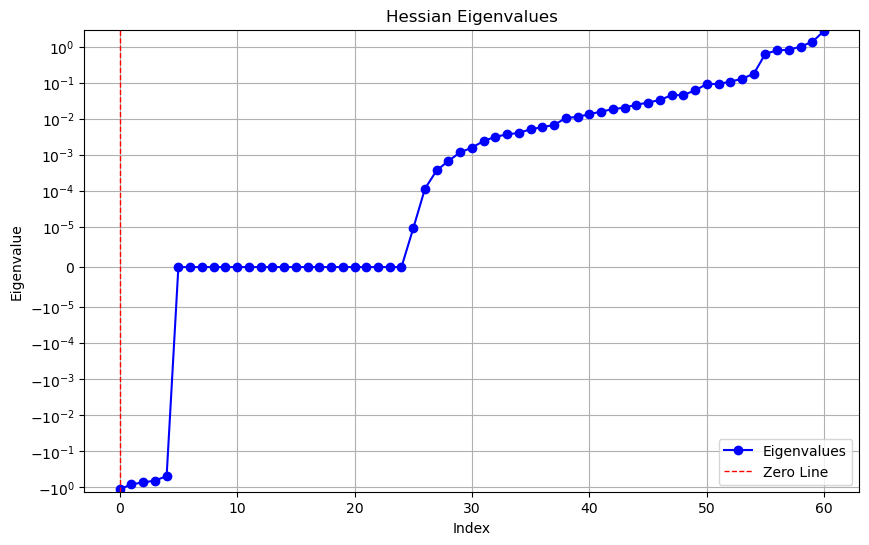

In [2]:
class HessianSpectraAnalyzer:
    def __init__(self, model, data_loader, loss_fn, device='cpu'):
        self.model = model.to(device)
        self.data_loader = data_loader
        self.loss_fn = loss_fn
        self.device = device

    def compute_hessian(self):
        """Compute the Hessian matrix of the loss w.r.t. model parameters."""
        self.model.zero_grad()
        x, y = next(iter(self.data_loader))
        x, y = x.to(self.device), y.to(self.device)
        output = self.model(x)
        loss = self.loss_fn(output, y)
        loss.backward(create_graph=True)

        params = [p for p in self.model.parameters() if p.requires_grad]
        num_params = sum(p.numel() for p in params)
        hessian = torch.zeros(num_params, num_params).to(self.device)
        
        # Compute Hessian using autograd
        for i in range(num_params):
            # 1. Zero out previous gradients
            self.model.zero_grad() 
            
            # 2. Extract the i-th component of the first gradient
            #    We need to compute the full first gradient first.
            grad1 = torch.autograd.grad(loss, params, create_graph=True, allow_unused=True)
            # Flatten all gradient tensors into a single vector
            grad1_vec = torch.cat([g.view(-1) for g in grad1 if g is not None])
            
            # Select the i-th element to compute its gradient
            if i < len(grad1_vec):
                grad_i = grad1_vec[i]
                
                # 3. Compute the gradient of the i-th component (the i-th row of the Hessian)
                grad2_i = torch.autograd.grad(grad_i, params, retain_graph=True, allow_unused=True)
                # Flatten the second gradient tensors into a single vector
                grad2_i_vec = torch.cat([g.view(-1) for g in grad2_i if g is not None])
                
                # 4. Assign the resulting vector to the i-th row of the Hessian matrix
                if len(grad2_i_vec) == num_params:
                    hessian[i] = grad2_i_vec
                else:
                    raise RuntimeError(f"Hessian row size mismatch: Expected {num_params}, got {len(grad2_i_vec)}")
            else:
                # Handle potential edge case if the grad1_vec is smaller than expected
                raise IndexError(f"Index {i} out of bounds for grad1_vec of size {len(grad1_vec)}")

        return hessian.cpu().numpy()

    def analyze_spectra(self, hessian):
        """Compute eigenvalues and eigenvectors of the Hessian."""
        eigenvalues, eigenvectors = eigh(hessian)
        return eigenvalues, eigenvectors

    def plot_spectra(self, eigenvalues):
        plt.figure(figsize=(10, 6))
        plt.plot(eigenvalues, 'o-', color='blue', label='Eigenvalues')
        plt.title('Hessian Eigenvalues')
        plt.xlabel('Index')
        plt.ylabel('Eigenvalue')
        plt.axvline(0, color='red', ls='--', lw=1, label='Zero Line')
        plt.yscale('symlog', linthresh=1e-5)  # Log scale for better visibility of small eigenvalues
        plt.grid(True)
        plt.legend()
        plt.show()

def main():
    # Example usage with a simple model and dataset
    class SimpleNN(nn.Module):
        def __init__(self):
            super(SimpleNN, self).__init__()
            self.fc1 = nn.Linear(10, 5)
            self.fc2 = nn.Linear(5, 1)
        def forward(self, x):
            x = F.relu(self.fc1(x))
            return self.fc2(x)

    # Create synthetic dataset
    X = torch.randn(100, 10)
    y = torch.randn(100, 1)
    dataset = TensorDataset(X, y)
    data_loader = DataLoader(dataset, batch_size=32)
    model = SimpleNN()
    loss_fn = nn.MSELoss()
    analyzer = HessianSpectraAnalyzer(model, data_loader, loss_fn)
    hessian = analyzer.compute_hessian()
    eigenvalues, _ = analyzer.analyze_spectra(hessian)
    analyzer.plot_spectra(eigenvalues)

if __name__ == '__main__':
    main()


max eigenvalue: 2.8611
min eigenvalue: -0.8776
spectral gap: 3.7387
recommended stable Δt: 6.9904e-01
condition number: 2861079199744.0000
Hessian trace: 5.8279


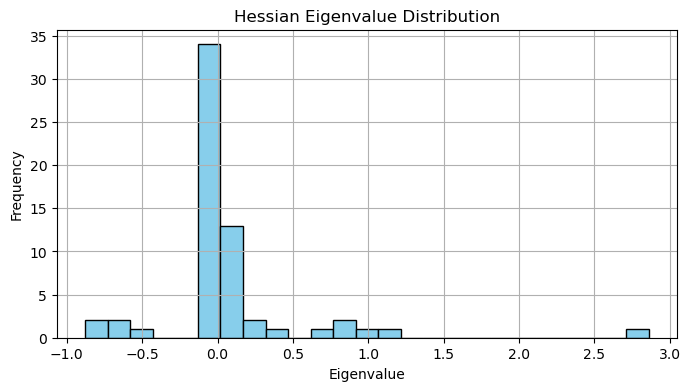

In [3]:
# Build a simple model and dataset for additional Hessian analysis
model = nn.Sequential(
    nn.Linear(10, 5),
    nn.ReLU(),
    nn.Linear(5, 1)
)

X = torch.randn(64, 10)
y = torch.randn(64, 1)
data_loader = DataLoader(TensorDataset(X, y), batch_size=32)

analyzer = HessianSpectraAnalyzer(model, data_loader, nn.MSELoss())
hessian = analyzer.compute_hessian()
eigenvalues, _ = analyzer.analyze_spectra(hessian)

spectral_gap = eigenvalues.max() - eigenvalues.min()
stable_dt = 2.0 / max(eigenvalues.max(), 1e-12)
condition_number = abs(eigenvalues.max() / max(eigenvalues.min(), 1e-12))
trace = eigenvalues.sum()

print(f"max eigenvalue: {eigenvalues.max():.4f}")
print(f"min eigenvalue: {eigenvalues.min():.4f}")
print(f"spectral gap: {spectral_gap:.4f}")
print(f"recommended stable Δt: {stable_dt:.4e}")
print(f"condition number: {condition_number:.4f}")
print(f"Hessian trace: {trace:.4f}")

plt.figure(figsize=(8, 4))
plt.hist(eigenvalues, bins=25, color='skyblue', edgecolor='black')
plt.title("Hessian Eigenvalue Distribution")
plt.xlabel("Eigenvalue")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()